<a href="https://colab.research.google.com/github/DianaBravoPerez/EDP-1/blob/main/Tutorial_Sympy_Networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial de SymPy y NetworkX

En este notebook voy a explicar cómo usar la librería **SymPy** para trabajar con matrices y también cómo usar **NetworkX** para dibujar un diagrama de transición.

Con ejemplos sencillos

---
## Parte 1: Matrices con SymPy

Primero hay que importar la librería. Con `from sympy import *` importamos todo.

In [2]:
from sympy import *

# Resultados con formato matemático)
init_printing(use_unicode=True)

### Representar una matriz

Para crear una matriz en SymPy usamos `Matrix()` y le pasamos una lista de listas. Cada lista interior es un renglón.

In [5]:
# Creo una matriz de 3x3
A = Matrix([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Matriz A:")
A

Matriz A:


⎡1  2  3⎤
⎢       ⎥
⎢4  5  6⎥
⎢       ⎥
⎣7  8  9⎦

In [6]:
# Creamos otra más pequeña para los ejemplos de abajo
B = Matrix([
    [2, 0],
    [1, 3]
])

print("Matriz B (2x2):")
B

Matriz B (2x2):


⎡2  0⎤
⎢    ⎥
⎣1  3⎦

### **Obtener entradas específicas (renglón, columna o elemento)**

Para acceder a los elementos de una matriz se usan índices, pero **empezando desde 0**.  

La sintaxis es: `A[renglón, columna]`

In [8]:
# Un elemento específico: renglón 0, columna 2 (o sea, primera fila, tercer elemento)
elemento = A[0, 2]
print("Elemento en renglón 0, columna 2:", elemento)

Elemento en renglón 0, columna 2: 3


In [10]:
# Un renglón completo: usamos .row()
# Nota: los índices también empiezan en 0
renglon1 = A.row(1)  # segundo renglón
print("Renglón 1 (el segundo):")
renglon1

Renglón 1 (el segundo):


[4  5  6]

In [11]:
# Una columna completa: uso .col()
columna0 = A.col(0)  # primera columna
print("Columna 0 (la primera):")
columna0

Columna 0 (la primera):


⎡1⎤
⎢ ⎥
⎢4⎥
⎢ ⎥
⎣7⎦

# **Multiplicar matrices**

Para multiplicar matrices en SymPy simplemente usamos el operador `*`. SymPy sabe que es multiplicación matricial, no elemento por elemento.

In [13]:
# Creamos dos matrices 2x2 para el ejemplo
M1 = Matrix([
    [1, 2],
    [3, 4]
])

M2 = Matrix([
    [5, 6],
    [7, 8]
])

# Multiplicación de matrices
resultado = M1 * M2
print("M1 * M2 =")
resultado

M1 * M2 =


⎡19  22⎤
⎢      ⎥
⎣43  50⎦

In [ ]:
# Nota: la multiplicación de matrices NO es conmutativa
print("M2 * M1 =")
M2 * M1

### **Elevar una matriz a una potencia**

Para elevar una matriz a una potencia usamos `**`.

In [14]:
# M1 al cuadrado (M1 * M1)
print("M1 al cuadrado (M1**2):")
M1**2

M1 al cuadrado (M1**2):


⎡7   10⎤
⎢      ⎥
⎣15  22⎦

In [16]:
# También elevamos a la 3
print("M1 al cubo (M1**3):")
M1**3

M1 al cubo (M1**3):


⎡37  54 ⎤
⎢       ⎥
⎣81  118⎦

In [17]:
# Con **-1 obtienes la inversa de la matriz
print("Inversa de M1 (M1**-1):")
M1**-1

Inversa de M1 (M1**-1):


⎡-2    1  ⎤
⎢         ⎥
⎣3/2  -1/2⎦

### **Multiplicar un vector por una matriz**

Un vector se puede representar como una matriz de una sola columna (vector columna) o un solo renglón (vector renglón). Lo más común es usar vector columna.

In [18]:
# Vector columna de 2 elementos
v = Matrix([1, 2])  # esto es un vector columna automáticamente

print("Vector v:")
print(v)
print()

# Multiplicar la matriz M1 por el vector
print("M1 * v =")
M1 * v

Vector v:
Matrix([[1], [2]])

M1 * v =


⎡5 ⎤
⎢  ⎥
⎣11⎦

In [19]:
# Nota: para multiplicar vector * matriz, el vector tiene que ir transpuesto, si no, las dimensiones no cuadran
vT = v.T  # transpuesta del vector (ahora es vector renglón)
print("v transpuesto * M1:")
vT * M1

v transpuesto * M1:


[7  10]

### **Valores y vectores propios (eigenvalores y eigenvectores)**

Los **valores propios** (eigenvalues) son escalares λ tal que `A*v = λ*v`, donde `v` es el **vector propio** (eigenvector) correspondiente.


In [20]:
# Uso M1 para el ejemplo
print("Matriz M1:")
M1

Matriz M1:


⎡1  2⎤
⎢    ⎥
⎣3  4⎦

In [22]:
# Calcular solo los valores propios con .eigenvals() y regresa un diccionario: {valor_propio: multiplicidad}
vals = M1.eigenvals()
print("Valores propios de M1:")
print(vals)

Valores propios de M1:
{5/2 - sqrt(33)/2: 1, 5/2 + sqrt(33)/2: 1}


In [24]:
# Calcular valores Y vectores propios con .eigenvects() y Regresa una lista de tuplas: (valor_propio, multiplicidad, [vectores])
vects = M1.eigenvects()
print("Valores y vectores propios de M1:")
print()
for val, mult, vecs in vects:
    print(f"  Valor propio: {val}  (multiplicidad {mult})")
    print(f"  Vector propio: {vecs[0].T}")
    print()

Valores y vectores propios de M1:

  Valor propio: 5/2 - sqrt(33)/2  (multiplicidad 1)
  Vector propio: Matrix([[-sqrt(33)/6 - 1/2, 1]])

  Valor propio: 5/2 + sqrt(33)/2  (multiplicidad 1)
  Vector propio: Matrix([[-1/2 + sqrt(33)/6, 1]])



In [26]:
# Verificación: se comprueba que A*v = lambda*v para el primer eigenpair
lambda1 = vects[0][0]
vec1    = vects[0][2][0]

lado_izq = M1 * vec1
lado_der = lambda1 * vec1

print("M1 * v1    =", lado_izq.T)
print("λ1  * v1   =", lado_der.T)
print("¿Son iguales?", simplify(lado_izq - lado_der) == zeros(2, 1))

M1 * v1    = Matrix([[3/2 - sqrt(33)/6, 5/2 - sqrt(33)/2]])
λ1  * v1   = Matrix([[(5/2 - sqrt(33)/2)*(-sqrt(33)/6 - 1/2), 5/2 - sqrt(33)/2]])
¿Son iguales? True


---
## Parte 2: Diagrama de transición con NetworkX

NetworkX es una librería para trabajar con grafos y redes. Un **diagrama de transición** es básicamente un grafo dirigido donde los nodos son estados y las flechas indican las transiciones posibles entre ellos (con probabilidades).

Se hará un ejemplo sencillo con 3 estados: Soleado, Nublado y Lluvioso.

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

In [28]:
# Se crea un grafo dirigido (DiGraph = Directed Graph)
G = nx.DiGraph()

# Agrego los nodos (los estados)
G.add_nodes_from(["Soleado", "Nublado", "Lluvioso"])

# Agrego las aristas con sus probabilidades de transición (de_estado, a_estado, probabilidad)
edges = [
    ("Soleado",  "Soleado",  0.7),
    ("Soleado",  "Nublado",  0.2),
    ("Soleado",  "Lluvioso", 0.1),
    ("Nublado",  "Soleado",  0.3),
    ("Nublado",  "Nublado",  0.4),
    ("Nublado",  "Lluvioso", 0.3),
    ("Lluvioso", "Soleado",  0.2),
    ("Lluvioso", "Nublado",  0.5),
    ("Lluvioso", "Lluvioso", 0.3),
]

for origen, destino, prob in edges:
    G.add_edge(origen, destino, weight=prob)

print("Nodos:", list(G.nodes))
print("Aristas:", list(G.edges))

Nodos: ['Soleado', 'Nublado', 'Lluvioso']
Aristas: [('Soleado', 'Soleado'), ('Soleado', 'Nublado'), ('Soleado', 'Lluvioso'), ('Nublado', 'Soleado'), ('Nublado', 'Nublado'), ('Nublado', 'Lluvioso'), ('Lluvioso', 'Soleado'), ('Lluvioso', 'Nublado'), ('Lluvioso', 'Lluvioso')]


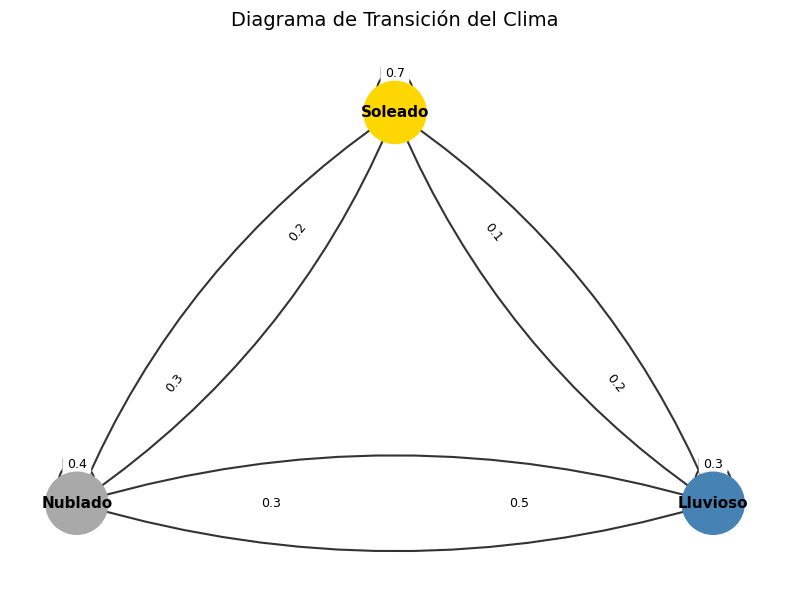

In [29]:
# Ahora el diagrama


fig, ax = plt.subplots(figsize=(8, 6))

# Posiciones de los nodos (las pongo a mano en círculo)
pos = {
    "Soleado":  (0, 1),
    "Nublado":  (-1, -0.5),
    "Lluvioso": (1, -0.5)
}

# Colores para cada nodo
colores = ["#FFD700", "#A9A9A9", "#4682B4"]  # amarillo, gris, azul

# Dibujar los nodos
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=colores, ax=ax)

# Dibujar etiquetas de los nodos
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold", ax=ax)

# Dibujar las aristas con flechas curvas
# connectionstyle="arc3,rad=0.1" hace que las flechas sean curvas
# así se ven mejor cuando hay flechas en ambas direcciones
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15",
    edge_color="#333333",
    width=1.5,
    ax=ax
)

# Etiquetas de las aristas (las probabilidades)
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=9,
    label_pos=0.3,
    ax=ax
)

ax.set_title("Diagrama de Transición del Clima", fontsize=14, pad=15)
ax.axis("off")
plt.tight_layout()
plt.show()

### Más sobre NetworkX

También podemos ver la **matriz de adyacencia** del grafo, que representa las mismas transiciones en forma de matriz.

In [30]:
# Matriz de adyacencia (con los pesos)
nodos_orden = ["Soleado", "Nublado", "Lluvioso"]
M_adyacencia = nx.to_numpy_array(G, nodelist=nodos_orden, weight="weight")

import pandas as pd
df = pd.DataFrame(M_adyacencia, index=nodos_orden, columns=nodos_orden)
print("Matriz de transición:")
df

Matriz de transición:


,Soleado,Nublado,Lluvioso
Soleado,0.7,0.2,0.1
Nublado,0.3,0.4,0.3
Lluvioso,0.2,0.5,0.3



**SymPy:**
- `Matrix([[...]])` → crear una matriz
- `A[i, j]`, `A.row(i)`, `A.col(j)` → acceder a entradas
- `A * B` → multiplicar matrices
- `A ** n` → elevar a una potencia
- `A * v` → multiplicar matriz por vector
- `A.eigenvals()` y `A.eigenvects()` → valores y vectores propios

**NetworkX:**
- `nx.DiGraph()` → crear un grafo dirigido
- `.add_nodes_from()` y `.add_edge()` → agregar nodos y aristas
- `nx.draw_networkx_*` + matplotlib → visualizar el grafo

Espero que haya quedado claro. A mí me ayudó mucho experimentar con los ejemplos y cambiar los valores para ver qué pasaba.